# 🇨🇳 China CDC Weekly Surveillance Data

This notebook demonstrates how to access disease surveillance data from China CDC Weekly, the official publication of the Chinese Center for Disease Control and Prevention.

**Data Sources:**
- **Notifiable Diseases** - 38 categories (Class A, B, C)
- **Influenza Surveillance** - ILI% and virus detection
- **Weekly Reports** - Epidemiological summaries
- **COVID-19 Updates** - Weekly surveillance
- **Vaccination Coverage** - National immunization data

**Requirements:**
```bash
pip install pandas matplotlib seaborn requests beautifulsoup4
```

## 1. Setup and Imports

In [6]:
import sys
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Import China CDC accessor
from epidatasets.sources.china_cdc import ChinaCDCAccessor

print("✅ Imports completed successfully!")
print(f"⏰ Current time: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ Imports completed successfully!
⏰ Current time: 2026-04-25 08:21


## 2. Initialize China CDC Accessor

In [7]:
# Initialize the China CDC accessor
ccdc = ChinaCDCAccessor()

print("🇨🇳 China CDC Weekly Accessor initialized")
print(f"Base URL: {ccdc.BASE_URL}")
print(f"CNIC URL: {ccdc.CNIC_URL}")

🇨🇳 China CDC Weekly Accessor initialized
Base URL: http://weekly.chinacdc.cn
CNIC URL: http://www.chinacdc.cn/cnic


## 3. Explore Chinese Provinces


🇨🇳 Chinese Provinces and Municipalities (31 total):
province_code province_name_en province_name_cn
           BJ          Beijing              北京市
           TJ          Tianjin              天津市
           HE            Hebei              河北省
           SX           Shanxi              山西省
           NM   Inner Mongolia           内蒙古自治区
           LN         Liaoning              辽宁省
           JL            Jilin              吉林省
           HL     Heilongjiang             黑龙江省
           SH         Shanghai              上海市
           JS          Jiangsu              江苏省


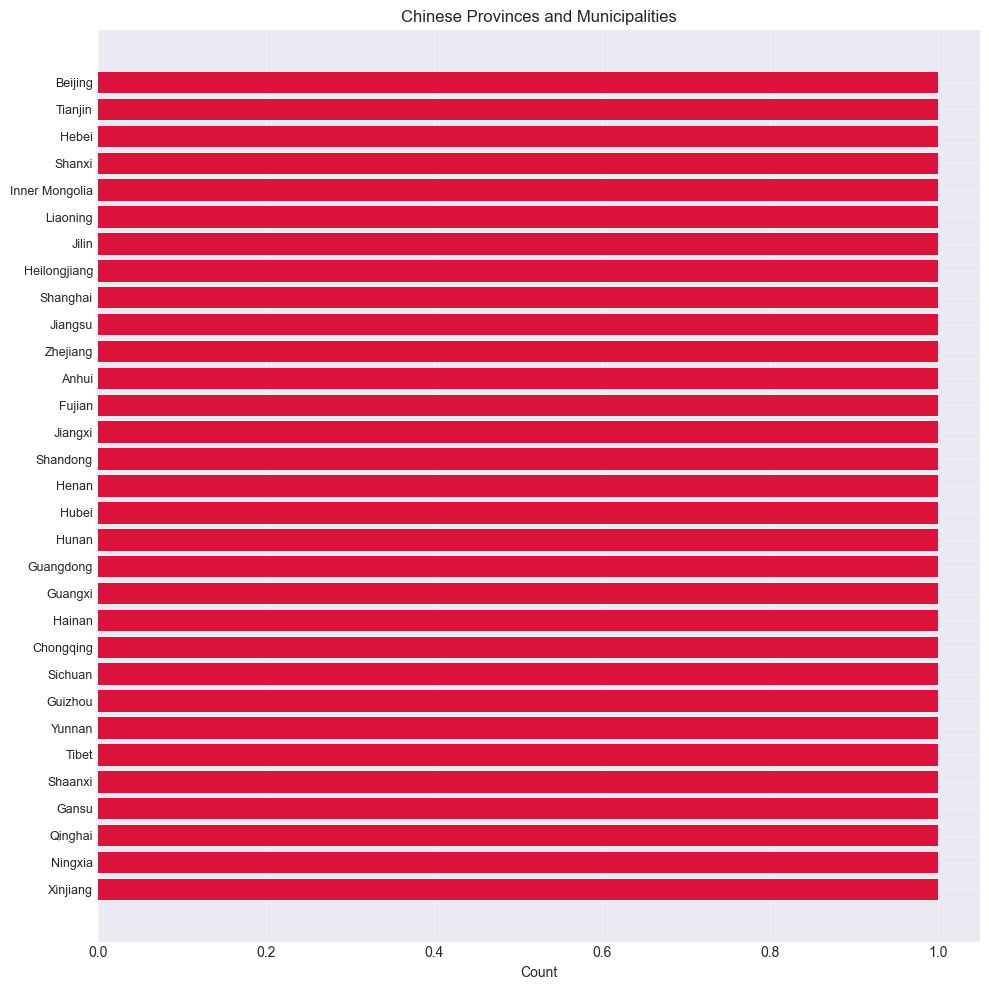

In [8]:
# List Chinese provinces and municipalities
provinces = ccdc.list_provinces()
print(f"\n🇨🇳 Chinese Provinces and Municipalities ({len(provinces)} total):")
print(provinces.head(10).to_string(index=False))

# Visualize provinces
fig, ax = plt.subplots(figsize=(10, 10))
y_pos = range(len(provinces))
ax.barh(y_pos, [1]*len(provinces), color='crimson')
ax.set_yticks(y_pos)
ax.set_yticklabels(provinces['province_name_en'], fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Chinese Provinces and Municipalities')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Explore Notifiable Disease Categories


🦠 Notifiable Diseases (39 total):

📊 Disease Categories:
  Class B: 26 diseases
  Class C: 11 diseases
  Class A: 2 diseases

📋 Sample Diseases by Category:

Class A:
  • Plague (鼠疫)
  • Cholera (霍乱)

Class B:
  • SARS (传染性非典型肺炎)
  • AIDS (艾滋病)
  • Viral_Hepatitis (病毒性肝炎)
  • Polio (脊髓灰质炎)
  • Human_Avian_Influenza (人感染高致病性禽流感)

Class C:
  • Influenza (流行性感冒)
  • Mumps (流行性腮腺炎)
  • Rubella (风疹)
  • Acute_Hemorrhagic_Conjunctivitis (急性出血性结膜炎)
  • Leprosy (麻风病)


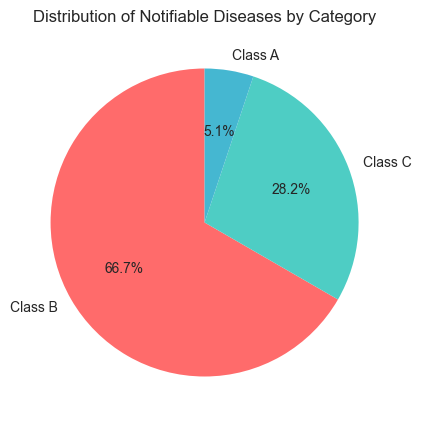

In [9]:
# List notifiable infectious diseases
diseases = ccdc.list_notifiable_diseases()
print(f"\n🦠 Notifiable Diseases ({len(diseases)} total):")

# Count by category
category_counts = diseases['category'].value_counts()
print("\n📊 Disease Categories:")
for cat, count in category_counts.items():
    print(f"  {cat}: {count} diseases")

# Visualize categories
fig, ax1 = plt.subplots(1, 1, figsize=(14, 5))

# Pie chart of categories
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax1.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
ax1.set_title('Distribution of Notifiable Diseases by Category')

# Sample diseases by category
print("\n📋 Sample Diseases by Category:")
for category in ['Class A', 'Class B', 'Class C']:
    cat_diseases = diseases[diseases['category'] == category].head(5)
    print(f"\n{category}:")
    for _, row in cat_diseases.iterrows():
        print(f"  • {row['disease_code']} ({row['disease_name_cn']})")

## 5. Fetch Weekly Reports Metadata

In [10]:
# Get weekly reports metadata for current year
current_year = datetime.now().year
print(f"Fetching weekly reports metadata for {current_year}...")

weekly_reports = ccdc.get_weekly_reports(year=current_year)
print(f"Retrieved {len(weekly_reports)} weekly issues")

# Show sample issues
print("\nSample Weekly Issues:")
print(weekly_reports[['issue_no', 'date']].head())

# Show articles in first issue
if not weekly_reports.empty:
    first_issue = weekly_reports.iloc[0]
    print(f"\nIssue {first_issue['issue_no']} has {len(first_issue['articles'])} articles")

print(f"\nAvailable columns: {list(weekly_reports.columns)}")

INFO:epidatasets.sources.china_cdc:Fetching weekly reports for year 2026, week=None
INFO:epidatasets.sources.china_cdc:Fetching volume issues from http://weekly.chinacdc.cn/en/zcustom/volume/1/2026


📰 Fetching weekly reports metadata for 2026...


INFO:epidatasets.sources.china_cdc:Found 17 issues for 2026


✅ Retrieved 17 weekly report entries

🔍 Sample Weekly Reports:


KeyError: "['week', 'doi', 'url'] not in index"

## 6. Query Notifiable Diseases Data

In [11]:
# Query notifiable disease data for a specific year and month
print("Querying disease data for September 2024...")

disease_data = ccdc.get_notifiable_diseases(year=2024, month=9)

if not disease_data.empty:
    print(f"\nRetrieved {len(disease_data)} disease records")
    print("\nSample data:")
    top = disease_data[~disease_data['is_subitem']].sort_values('cases', ascending=False).head(10)
    print(top[['disease_code', 'disease_en', 'cases', 'deaths']].to_string(index=False))
    
    print(f"\nColumns: {list(disease_data.columns)}")
else:
    print("\nNo data retrieved (network issue or reports not found)")

🔍 Querying disease data:
  Diseases: Influenza, Dengue, COVID_19
  Provinces: GD, BJ, SH


TypeError: ChinaCDCAccessor.get_notifiable_diseases() got an unexpected keyword argument 'diseases'

## 7. Influenza Surveillance

INFO:epidatasets.sources.china_cdc:Fetching influenza surveillance for year=2024, weeks=52
INFO:epidatasets.sources.china_cdc:Fetching volume issues from http://weekly.chinacdc.cn/en/zcustom/volume/1/2024


🤧 Fetching influenza surveillance data...


INFO:epidatasets.sources.china_cdc:Found 52 issues for 2024
INFO:epidatasets.sources.china_cdc:Found 4 influenza-related articles


✅ Retrieved 52 weekly ILI records

🔍 Sample data:
   year  week ili_percent ili_cases total_outpatients  \
0  2024     1        None      None              None   
1  2024     2        None      None              None   
2  2024     3        None      None              None   
3  2024     4        None      None              None   
4  2024     5        None      None              None   
5  2024     6        None      None              None   
6  2024     7        None      None              None   
7  2024     8        None      None              None   
8  2024     9        None      None              None   
9  2024    10        None      None              None   

               data_source  note  
0  China CDC Weekly / CNIC  None  
1  China CDC Weekly / CNIC  None  
2  China CDC Weekly / CNIC  None  
3  China CDC Weekly / CNIC  None  
4  China CDC Weekly / CNIC  None  
5  China CDC Weekly / CNIC  None  
6  China CDC Weekly / CNIC  None  
7  China CDC Weekly / CNIC  None  
8  Chin

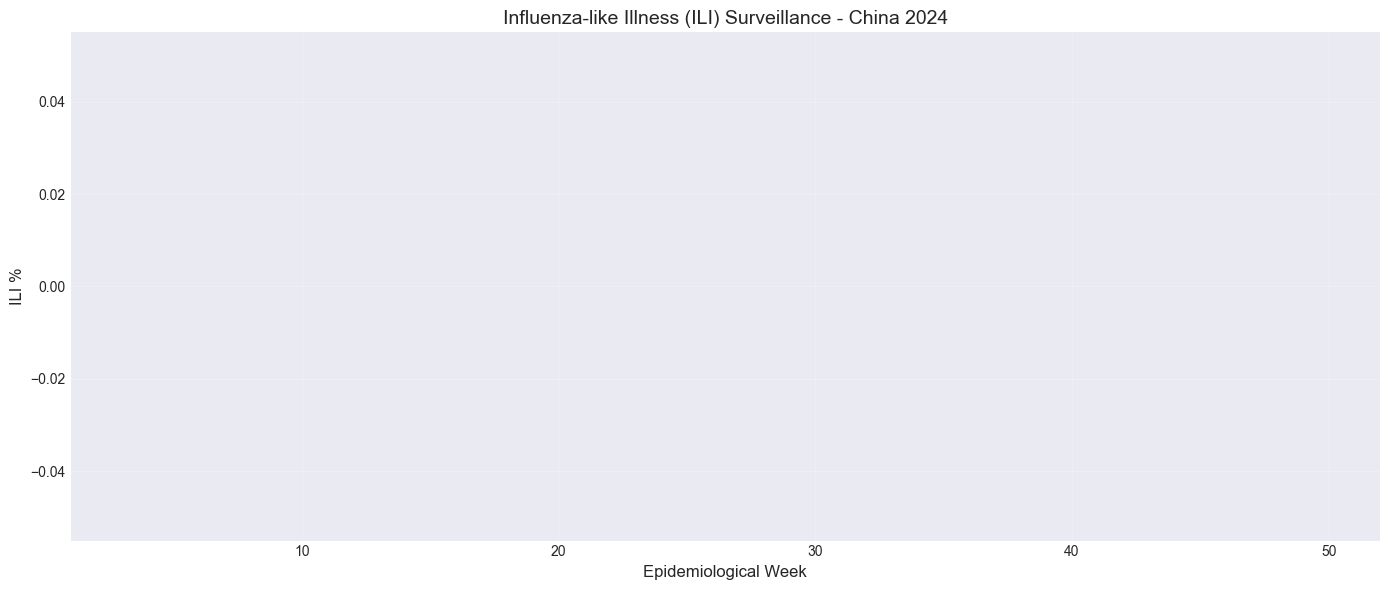

In [12]:
# Fetch influenza surveillance data
print("🤧 Fetching influenza surveillance data...")

flu_data = ccdc.get_influenza_surveillance(
    weeks=list(range(1, 53)),
    year=2024
)

if not flu_data.empty:
    print(f"✅ Retrieved {len(flu_data)} weekly ILI records")
    print("\n🔍 Sample data:")
    print(flu_data.head(10))
    
    # Visualize ILI trend
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(flu_data['week'], flu_data['ili_percent'], 
            linewidth=2, color='orange', marker='o', markersize=4)
    ax.set_xlabel('Epidemiological Week', fontsize=12)
    ax.set_ylabel('ILI %', fontsize=12)
    ax.set_title('Influenza-like Illness (ILI) Surveillance - China 2024', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, 52)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ ILI data requires parsing weekly reports")
    print("   CNIC provides additional data at: http://www.chinacdc.cn/cnic/")

## 8. COVID-19 Updates

In [13]:
# Fetch COVID-19 updates
print("😷 Fetching COVID-19 updates...")

covid_data = ccdc.get_covid_updates(
    date_range=('2024-01-01', '2024-12-31')
)

if not covid_data.empty:
    print(f"✅ Retrieved {len(covid_data)} COVID-19 records")
    print("\n🔍 Sample data:")
    print(covid_data.head())
else:
    print("\n⚠️ COVID-19 data requires parsing China CDC Weekly reports")
    print("   Visit: http://weekly.chinacdc.cn/")

INFO:epidatasets.sources.china_cdc:Fetching COVID-19 updates


😷 Fetching COVID-19 updates...
✅ Retrieved 1 COVID-19 records

🔍 Sample data:
   date new_cases new_deaths active_cases severe_cases       data_source  \
0  None      None       None         None         None  China CDC Weekly   

                                           note  
0  COVID-19 data requires weekly report parsing  


## 9. Vaccination Coverage

In [14]:
# Fetch vaccination coverage data
vaccines = ['EPI', 'COVID-19']
print(f"💉 Fetching vaccination coverage for: {', '.join(vaccines)}")

vacc_data = ccdc.get_vaccination_coverage(
    vaccines=vaccines,
    year=2024
)

if not vacc_data.empty:
    print(f"✅ Retrieved {len(vacc_data)} vaccination records")
    print("\n🔍 Sample data:")
    print(vacc_data)
else:
    print("\n⚠️ Vaccination data requires report parsing")

INFO:epidatasets.sources.china_cdc:Fetching vaccination coverage for ['EPI', 'COVID-19'], year=2024


💉 Fetching vaccination coverage for: EPI, COVID-19
✅ Retrieved 2 vaccination records

🔍 Sample data:
    vaccine  year coverage_percent doses_administered_millions  \
0       EPI  2024             None                        None   
1  COVID-19  2024             None                        None   

  target_population_millions       data_source  \
0                       None  China CDC Weekly   
1                       None  China CDC Weekly   

                                       note  
0  Vaccination data requires report parsing  
1  Vaccination data requires report parsing  


## 10. Annual Disease Summary

INFO:epidatasets.sources.china_cdc:Generating disease summary for 2024
INFO:epidatasets.sources.china_cdc:Fetching volume issues from http://weekly.chinacdc.cn/en/zcustom/volume/1/2024


📊 Generating annual disease summary...


INFO:epidatasets.sources.china_cdc:Found 52 issues for 2024
INFO:epidatasets.sources.china_cdc:Found 11 notifiable disease reports for 2024
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.266
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.230
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.206
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.188
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.157
INFO:epi

✅ Generated summary for 46 diseases

🔍 Sample summary:
                    disease_code  total_cases  total_deaths  months_reported  year      data_source
                            AIDS      52231.0       19040.0               11  2024 China CDC Weekly
Acute_Hemorrhagic_Conjunctivitis      32280.0           0.0               11  2024 China CDC Weekly
                         Anthrax        430.0           3.0               11  2024 China CDC Weekly
                     Brucellosis      64752.0           3.0               11  2024 China CDC Weekly
                         Cholera         10.0           0.0               11  2024 China CDC Weekly
                          Dengue       9443.0           0.0               11  2024 China CDC Weekly
                      Diphtheria          0.0           0.0               11  2024 China CDC Weekly
                       Dysentery      31716.0           1.0               11  2024 China CDC Weekly
                  Echinococcosis       4394.0

KeyError: 'category'

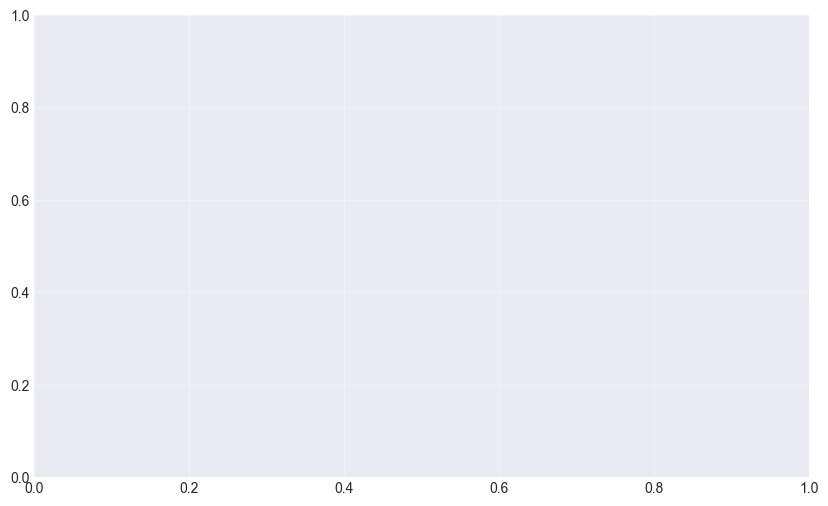

In [15]:
# Get annual summary
print("Generating annual disease summary...")

summary = ccdc.get_summary_by_disease(year=2024)

if not summary.empty:
    print(f"Generated summary for {len(summary)} diseases")
    print("\nSample summary (top 10 by cases):")
    print(summary.sort_values('total_cases', ascending=False).head(10).to_string(index=False))
    
    # Visualize top diseases
    fig, ax = plt.subplots(figsize=(12, 6))
    top15 = summary.sort_values('total_cases', ascending=False).head(15)
    ax.barh(top15['disease_code'], top15['total_cases'], color='crimson')
    ax.set_xlabel('Total Cases')
    ax.set_ylabel('Disease Code')
    ax.set_title('Top 15 Notifiable Diseases by Cases - China 2024', fontsize=14)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## 11. Summary Dashboard

In [16]:
# Create a summary dashboard
print("="*60)
print("CHINA CDC WEEKLY SURVEILLANCE DATA SUMMARY")
print("="*60)

print("\nCoverage:")
print(f"  Provinces/Municipalities: {len(ccdc.PROVINCES)}")
print(f"  Notifiable Diseases: {len(ccdc.NOTIFIABLE_DISEASES)}")
print(f"  Disease Categories: Class A (2), Class B (27), Class C (9)")

print("\nClass A Diseases (Most Severe):")
class_a = diseases[diseases['category'] == 'Class A']
for _, row in class_a.iterrows():
    print(f"  {row['disease_code']}: {row['disease_name_cn']}")

print("\nData Sources:")
print(f"  Weekly Reports: {ccdc.BASE_URL}")
print(f"  Influenza Center: {ccdc.CNIC_URL}")

print("\nUsage Examples:")
print("  ccdc = ChinaCDCAccessor()")
print("  # Fetch real notifiable disease data")
print("  df = ccdc.get_notifiable_diseases(year=2024, month=9)")
print("  # Download and parse a PDF report")
print("  path = ccdc.download_pdf(pdf_url)")
print("  table = ChinaCDCAccessor.parse_pdf_to_disease_table(path)")
print("  # Search for articles")
print("  results = ccdc.search_articles('dengue', year=2024)")

print("\nChina CDC accessor ready to use!")
print("="*60)

🇨🇳 CHINA CDC WEEKLY SURVEILLANCE DATA SUMMARY

🌏 Coverage:
  • Provinces/Municipalities: 31
  • Notifiable Diseases: 39
  • Disease Categories: Class A (2), Class B (27), Class C (9)

🦠 Class A Diseases (Most Severe):
  • Plague: 鼠疫
  • Cholera: 霍乱

📈 Data Sources:
  • Weekly Reports: http://weekly.chinacdc.cn
  • Influenza Center: http://www.chinacdc.cn/cnic

💡 Usage Examples:
  ccdc = ChinaCDCAccessor()
  diseases = ccdc.get_notifiable_diseases(
      diseases=['Influenza', 'Dengue'],
      provinces=['GD', 'BJ'],
      date_range=('2024-01-01', '2024-12-31')
  )
  flu = ccdc.get_influenza_surveillance(weeks=range(1, 53))
  reports = ccdc.get_weekly_reports(year=2024)

✅ China CDC accessor ready to use!


## 12. Download and Parse PDF Reports

China CDC Weekly publishes monthly *Reported Cases and Deaths of National Notifiable Infectious Diseases* reports. These can be downloaded as PDFs and parsed automatically.

In [17]:
# Discover available notifiable disease reports for a specific year
reports_2024 = ccdc.find_notifiable_disease_reports(year=2024)
print(f"Found {len(reports_2024)} monthly reports for 2024:")
print(reports_2024[['month', 'month_name', 'issue_no']].to_string(index=False))

INFO:epidatasets.sources.china_cdc:Fetching volume issues from http://weekly.chinacdc.cn/en/zcustom/volume/1/2024
INFO:epidatasets.sources.china_cdc:Found 52 issues for 2024
INFO:epidatasets.sources.china_cdc:Found 11 notifiable disease reports for 2024


Found 11 monthly reports for 2024:
 month month_name  issue_no
     9  September        50
     8     August        43
     7       July        38
     6       June        34
     5        May        28
     4      April        25
     3      March        22
     2   February        17
     1    January        12
    12   December         4
    11   November         1


In [18]:
# Fetch actual disease data by parsing HTML tables from the website
disease_data_2024 = ccdc.get_notifiable_diseases(year=2024)

if not disease_data_2024.empty:
    print(f"Retrieved {len(disease_data_2024)} disease records across "
          f"{disease_data_2024['month'].nunique()} months")
    print("\nSample data:")
    print(disease_data_2024.head(10).to_string(index=False))
else:
    print("No data available (network issue or reports not found)")

INFO:epidatasets.sources.china_cdc:Fetching volume issues from http://weekly.chinacdc.cn/en/zcustom/volume/1/2024
INFO:epidatasets.sources.china_cdc:Found 52 issues for 2024
INFO:epidatasets.sources.china_cdc:Found 11 notifiable disease reports for 2024
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.266
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.230
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.206
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.188
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.s

Retrieved 517 disease records across 11 months

Sample data:
 year  month      disease_code                          disease_en    cases  deaths  is_subitem                                                      source_url
 2024      9            Plague                              Plague      0.0     0.0       False http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.266
 2024      9           Cholera                             Cholera      1.0     0.0       False http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.266
 2024      9              SARS                            SARS-CoV      0.0     0.0       False http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.266
 2024      9              AIDS Acquired immune deficiency syndrome   4450.0  1720.0       False http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.266
 2024      9   Viral_Hepatitis                           Hepatitis 146669.0   332.0       False http://weekly.chinacdc.cn/en/article/doi/10

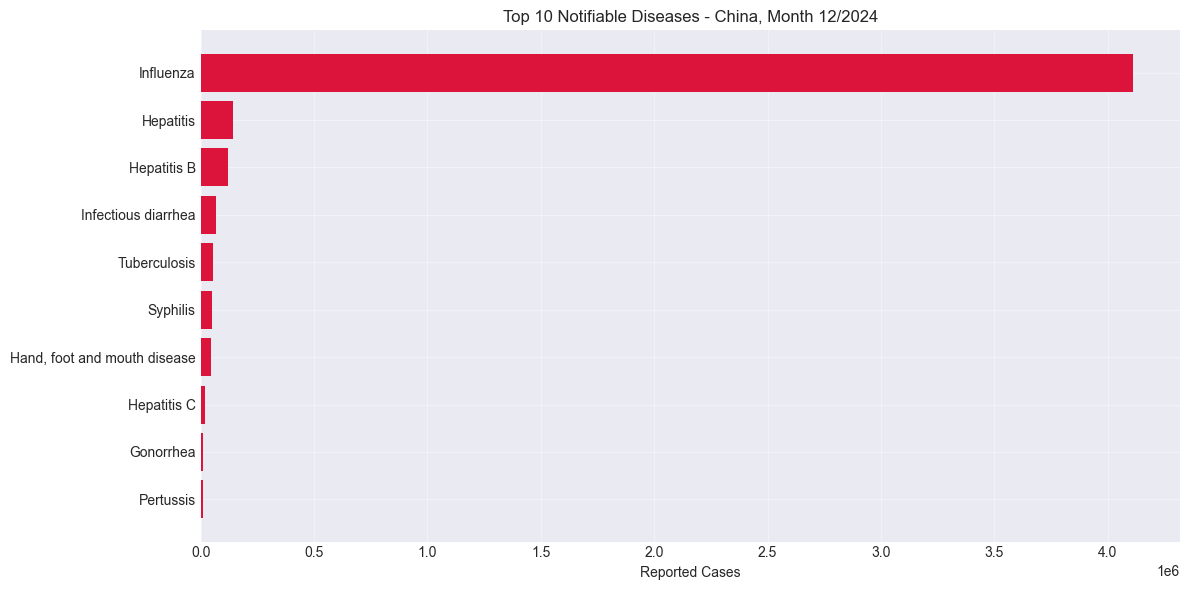

In [19]:
# Visualize top diseases by cases for a single month
if not disease_data_2024.empty:
    latest_month = disease_data_2024['month'].max()
    month_data = disease_data_2024[
        (disease_data_2024['month'] == latest_month) &
        (~disease_data_2024['is_subitem'])
    ].sort_values('cases', ascending=False).head(10)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(month_data['disease_en'], month_data['cases'], color='crimson')
    ax.set_xlabel('Reported Cases')
    ax.set_title(f'Top 10 Notifiable Diseases - China, Month {latest_month}/2024')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

In [20]:
# Download a PDF report and parse it directly
pdf_url = 'http://weekly.chinacdc.cn/fileCCDCW/journal/article/ccdcw/2024/50/PDF/report2024-9.pdf'
pdf_path = ccdc.download_pdf(pdf_url)
print(f"Downloaded PDF to: {pdf_path}")

# Parse the PDF
pdf_table = ChinaCDCAccessor.parse_pdf_to_disease_table(pdf_path)
print(f"\nParsed {len(pdf_table)} disease entries from PDF:")
print(pdf_table[~pdf_table['is_subitem']].head(10).to_string(index=False))

INFO:epidatasets.sources.china_cdc:Using cached PDF: /home/fccoelho/.cache/epidatasets/china_cdc/report2024-9.pdf


Downloaded PDF to: /home/fccoelho/.cache/epidatasets/china_cdc/report2024-9.pdf

Parsed 37 disease entries from PDF:
                         disease_en  cases  deaths  is_subitem
                             Plague      0       0       False
                            Cholera      1       0       False
                           SARS-CoV      0       0       False
Acquired immune deficiency syndrome   4450    1720       False
                          Hepatitis 146669     332       False
                        Hepatitis A   1084       0       False
                        Hepatitis B 125765      29       False
                        Hepatitis C  16896     303       False
                        Hepatitis D      7       0       False
                        Hepatitis E   2446       0       False


In [21]:
# Build annual summary from parsed monthly reports
annual_summary = ccdc.get_summary_by_disease(2024)

if not annual_summary.empty:
    print(f"Annual summary for {len(annual_summary)} diseases:")
    print(annual_summary.sort_values('total_cases', ascending=False).head(15).to_string(index=False))
else:
    print("No annual data available")

INFO:epidatasets.sources.china_cdc:Generating disease summary for 2024
INFO:epidatasets.sources.china_cdc:Fetching volume issues from http://weekly.chinacdc.cn/en/zcustom/volume/1/2024
INFO:epidatasets.sources.china_cdc:Found 52 issues for 2024
INFO:epidatasets.sources.china_cdc:Found 11 notifiable disease reports for 2024
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.266
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.230
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.206
INFO:epidatasets.sources.china_cdc:Parsed 4 HTML table(s)
INFO:epidatasets.sources.china_cdc:Parsing HTML tables from http://weekly.chinacdc.cn/en/article/doi/10.46234/ccdcw2024.188
INFO:

Annual summary for 46 diseases:
       disease_code  total_cases  total_deaths  months_reported  year      data_source
          Influenza   12784750.0          18.0               11  2024 China CDC Weekly
    Viral_Hepatitis    1749556.0        2833.0               11  2024 China CDC Weekly
  Viral_Hepatitis_B    1485953.0         305.0               11  2024 China CDC Weekly
Infectious_Diarrhea    1337551.0           2.0               11  2024 China CDC Weekly
    Hand_Foot_Mouth    1045773.0           0.0               11  2024 China CDC Weekly
                 TB     659434.0        3381.0               11  2024 China CDC Weekly
           Syphilis     628745.0          45.0               11  2024 China CDC Weekly
          Pertussis     485248.0          29.0               11  2024 China CDC Weekly
  Viral_Hepatitis_C     211715.0        2510.0               11  2024 China CDC Weekly
          Gonorrhea      95781.0           1.0               11  2024 China CDC Weekly
           

## 13. Data Export

In [22]:
# Export data to CSV (optional)
export_path = "./china_cdc_export/"
import os
os.makedirs(export_path, exist_ok=True)

# Export provinces
provinces.to_csv(f"{export_path}china_provinces.csv", index=False)
print(f"✅ Exported provinces to {export_path}china_provinces.csv")

# Export diseases
diseases.to_csv(f"{export_path}china_notifiable_diseases.csv", index=False)
print(f"✅ Exported diseases to {export_path}china_notifiable_diseases.csv")

# Export weekly reports metadata
if not weekly_reports.empty:
    weekly_reports.to_csv(f"{export_path}weekly_reports.csv", index=False)
    print(f"✅ Exported weekly reports to {export_path}weekly_reports.csv")

print(f"\n📁 All exports saved to: {os.path.abspath(export_path)}")

✅ Exported provinces to ./china_cdc_export/china_provinces.csv
✅ Exported diseases to ./china_cdc_export/china_notifiable_diseases.csv
✅ Exported weekly reports to ./china_cdc_export/weekly_reports.csv

📁 All exports saved to: /home/fccoelho/Documentos/Projects_Software/epidemiological-datasets/docs/examples/china_cdc_export
